# Deep Dive: Discrete-Time LTI Identification

This notebook compares two Bayesian parameterizations for a discrete-time linear time-invariant (LTI) state-space model in `dynestyx`:

1. **Standard form** (directly sample entries of `A, B, C`)
2. **Canonical form** (sample companion coefficients uniformly in the stability triangle)

We focus on:

- parameter recovery,
- predictive performance,
- stability behavior,
- and practical identifiability differences.

The setup is:

- state dimension `d_x = 2`
- control dimension `d_u = 1`
- observation dimension `d_y = 1`
- no biases, and `D = 0`
- `x_0 ~ N(0, I)`
- process noise `Q = sigma_state^2 I`
- observation noise `R = sigma_obs^2 I`
- sequence length `T = 400`
- controls `u_t ~ N(0, 1)` iid.

## Imports and global configuration

We use:

- `dynestyx` for simulation and exact Kalman-filter marginalization,
- `numpyro`/`jax` for Bayesian inference,
- `matplotlib` for diagnostics and posterior plots.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, Filter, LTI_discrete
from dynestyx.inference.filter_configs import KFConfig

numpyro.set_host_device_count(1)

# Problem dimensions
STATE_DIM = 2
CONTROL_DIM = 1
OBS_DIM = 1
T = 400

# Prior support for canonical eigenvalue prior
LAMBDA_MAX = 0.98

# Inference config (adjust for speed/quality trade-off)
NUM_WARMUP = 1000
NUM_SAMPLES = 5000

rng = jr.PRNGKey(0)

## 1) Ground-truth system generation

We generate a stable `A_true` using eigendecomposition:

1. sample two real eigenvalues inside the unit disk,
2. sample a random orthogonal matrix `V`,
3. set `A_true = V @ diag(lam) @ V.T`.

Then sample `B_true` and `C_true` entrywise from `N(0,1)`, and choose positive noise scales.

This gives a diverse yet stable LTI system.

In [2]:
def random_orthogonal(key, dim=2):
    """Sample a Haar-like random orthogonal matrix via QR."""
    m = jr.normal(key, (dim, dim))
    q, r = jnp.linalg.qr(m)
    # Fix sign ambiguity so distribution is approximately uniform on O(dim)
    s = jnp.sign(jnp.diag(r))
    s = jnp.where(s == 0, 1.0, s)
    q = q * s
    return q


def sample_stable_A(key, rho=0.98):
    """Construct A = V diag(lam) V^T with |lam_i| < rho."""
    k_eig, k_v = jr.split(key)
    lam = jr.uniform(k_eig, (STATE_DIM,), minval=-rho, maxval=rho)
    V = random_orthogonal(k_v, dim=STATE_DIM)
    A = V @ jnp.diag(lam) @ V.T
    return A, lam, V


def spectral_radius(A):
    eigvals = jnp.linalg.eigvals(A)
    return jnp.max(jnp.abs(eigvals))


rng, kA, kB, kC, ku, ksim = jr.split(rng, 6)

A_true, lam_true, V_true = sample_stable_A(kA, rho=LAMBDA_MAX)
B_true = jr.normal(kB, (STATE_DIM, CONTROL_DIM))
C_true = jr.normal(kC, (OBS_DIM, STATE_DIM))
sigma_state_true = 0.20
sigma_obs_true = 0.35

Q_true = (sigma_state_true**2) * jnp.eye(STATE_DIM)
R_true = (sigma_obs_true**2) * jnp.eye(OBS_DIM)

obs_times = jnp.arange(T, dtype=jnp.float32)
ctrl_times = obs_times
ctrl_values = jr.normal(ku, (T, CONTROL_DIM))

print('A_true:\n', A_true)
print('eig(A_true)=', jnp.linalg.eigvals(A_true))
print('spectral radius(A_true)=', float(spectral_radius(A_true)))
print('B_true shape:', B_true.shape, 'C_true shape:', C_true.shape)
print('controls shape:', ctrl_values.shape)

A_true:
 [[ 0.11868506 -0.1545046 ]
 [-0.15450458 -0.5118027 ]]
eig(A_true)= [ 0.15451151+0.j -0.5476291 +0.j]
spectral radius(A_true)= 0.5476291179656982
B_true shape: (2, 1) C_true shape: (1, 2)
controls shape: (400, 1)


In [3]:
def lti_forward_model(A, B, C, sigma_state, sigma_obs, obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None):
    """Shared dynestyx LTI model with D=0 and no biases."""
    Q = (sigma_state**2) * jnp.eye(STATE_DIM)
    R = (sigma_obs**2) * jnp.eye(OBS_DIM)
    D = jnp.zeros((OBS_DIM, CONTROL_DIM))
    dynamics = LTI_discrete(
        A=A,
        Q=Q,
        H=C,
        R=R,
        B=B,
        D=D,
        initial_mean=jnp.zeros(STATE_DIM),
        initial_cov=jnp.eye(STATE_DIM),
    )
    return dsx.sample(
        'f',
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )


def true_data_model(obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None):
    return lti_forward_model(
        A=A_true,
        B=B_true,
        C=C_true,
        sigma_state=sigma_state_true,
        sigma_obs=sigma_obs_true,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )


pred_true = Predictive(true_data_model, num_samples=1, exclude_deterministic=False)
with DiscreteTimeSimulator():
    synthetic = pred_true(ksim, obs_times=obs_times, ctrl_times=ctrl_times, ctrl_values=ctrl_values)

x_true = synthetic['states'][0]          # (T, 2)
y_obs = synthetic['observations'][0]     # (T, 1)

print('x_true shape:', x_true.shape)
print('y_obs shape:', y_obs.shape)

x_true shape: (400, 2)
y_obs shape: (400, 1)


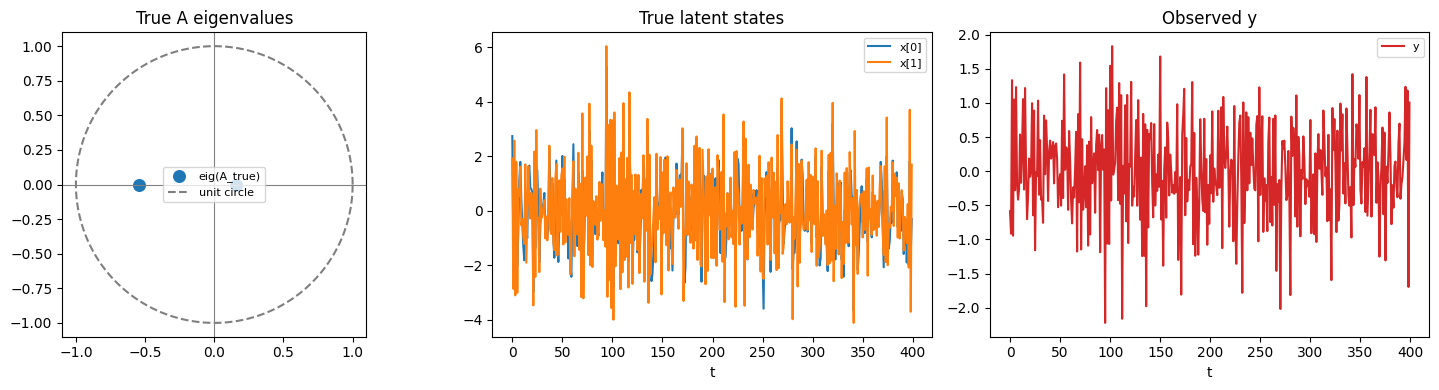

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# True eigenvalues
ax = axs[0]
lam_plot = np.array(jnp.linalg.eigvals(A_true))
ax.scatter(lam_plot.real, lam_plot.imag, c='C0', s=70, label='eig(A_true)')
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5, label='unit circle')
ax.axhline(0.0, color='gray', lw=0.8)
ax.axvline(0.0, color='gray', lw=0.8)
ax.set_aspect('equal', 'box')
ax.set_title('True A eigenvalues')
ax.legend(fontsize=8)

# State trajectories
axs[1].plot(np.array(x_true[:, 0]), label='x[0]')
axs[1].plot(np.array(x_true[:, 1]), label='x[1]')
axs[1].set_title('True latent states')
axs[1].set_xlabel('t')
axs[1].legend(fontsize=8)

# Observation trajectory
axs[2].plot(np.array(y_obs[:, 0]), color='C3', label='y')
axs[2].set_title('Observed y')
axs[2].set_xlabel('t')
axs[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 2) Two Bayesian model parameterizations

### Model 1: Standard form

Sample all entries of `A, B, C` directly with i.i.d. Normal priors, plus positive priors on noise scales.

### Model 2: Canonical form with a stability-triangle prior

Use a 2D companion matrix

\[
A = \begin{bmatrix}
0 & 1 \\
-a_0 & -a_1
\end{bmatrix}
\]

and place a **uniform prior** on `(a0, a1)` over the discrete-time stability triangle:

\[
|a_0| < 1,
\qquad
|a_1| < 1 + a_0.
\]

This is the standard Schur-stability region for second-order real polynomials and guarantees stable eigenvalues for the companion `A`.

In [5]:
def standard_model(obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None):
    """Direct parameterization: A, B, C entries have iid Normal priors."""
    A = numpyro.sample('A', dist.Normal(0.0, 1.0).expand([STATE_DIM, STATE_DIM]).to_event(2))
    B = numpyro.sample('B', dist.Normal(0.0, 1.0).expand([STATE_DIM, CONTROL_DIM]).to_event(2))
    C = numpyro.sample('C', dist.Normal(0.0, 1.0).expand([OBS_DIM, STATE_DIM]).to_event(2))

    sigma_state = numpyro.sample('sigma_state', dist.HalfNormal(0.5))
    sigma_obs = numpyro.sample('sigma_obs', dist.HalfNormal(0.5))

    return lti_forward_model(
        A=A,
        B=B,
        C=C,
        sigma_state=sigma_state,
        sigma_obs=sigma_obs,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )


def canonical_companion_A(a0, a1):
    """2x2 companion matrix with coefficients from characteristic polynomial."""
    return jnp.array([[0.0, 1.0], [-a0, -a1]])


def sample_uniform_stability_triangle():
    """Uniform sample on triangle vertices (-1,0), (1,2), (1,-2)."""
    u = numpyro.sample('tri_u', dist.Uniform(0.0, 1.0))
    v = numpyro.sample('tri_v', dist.Uniform(0.0, 1.0))
    # Reflect to get uniform barycentric coordinates on the reference simplex
    u_ref = jnp.where(u + v > 1.0, 1.0 - u, u)
    v_ref = jnp.where(u + v > 1.0, 1.0 - v, v)

    v0 = jnp.array([-1.0, 0.0])
    v1 = jnp.array([1.0, 2.0])
    v2 = jnp.array([1.0, -2.0])
    point = v0 + u_ref * (v1 - v0) + v_ref * (v2 - v0)
    return point[0], point[1]


def canonical_model(obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None):
    """Canonical parameterization: learn a0, a1, C and noise scales."""
    a0, a1 = sample_uniform_stability_triangle()

    # Complex-safe quadratic roots for z^2 + a1 z + a0 = 0
    disc_c = (a1**2 - 4.0 * a0).astype(jnp.complex64)
    sqrt_disc = jnp.sqrt(disc_c)
    lam1 = (-a1 + sqrt_disc) / 2.0
    lam2 = (-a1 - sqrt_disc) / 2.0

    A = canonical_companion_A(a0, a1)
    B = jnp.array([[0.0], [1.0]])
    C = numpyro.sample('C', dist.Normal(0.0, 1.0).expand([OBS_DIM, STATE_DIM]).to_event(2))

    sigma_state = numpyro.sample('sigma_state', dist.HalfNormal(0.5))
    sigma_obs = numpyro.sample('sigma_obs', dist.HalfNormal(0.5))

    numpyro.deterministic('a0', a0)
    numpyro.deterministic('a1', a1)
    numpyro.deterministic('lambda1_real', jnp.real(lam1))
    numpyro.deterministic('lambda1_imag', jnp.imag(lam1))
    numpyro.deterministic('lambda2_real', jnp.real(lam2))
    numpyro.deterministic('lambda2_imag', jnp.imag(lam2))
    numpyro.deterministic('A', A)
    numpyro.deterministic('B', B)

    return lti_forward_model(
        A=A,
        B=B,
        C=C,
        sigma_state=sigma_state,
        sigma_obs=sigma_obs,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )

## 3) Posterior inference with exact KF-marginalized likelihood

For both parameterizations, we condition on `y_obs` and run `NUTS` with `Filter(KFConfig())`.

Because the model is linear-Gaussian conditional on parameters, this uses exact Kalman filtering for latent-state marginalization.

In [6]:
def make_conditioned_model(base_model, y):
    def conditioned_model():
        with Filter(filter_config=KFConfig()):
            return base_model(
                obs_times=obs_times,
                obs_values=y,
                ctrl_times=ctrl_times,
                ctrl_values=ctrl_values,
            )

    return conditioned_model


def run_mcmc(model, key, name):
    nuts = NUTS(model)
    mcmc = MCMC(nuts, num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES)
    mcmc.run(key)
    mcmc.print_summary(exclude_deterministic=False)
    samples = mcmc.get_samples(group_by_chain=False)
    print(f'[{name}] sites:', sorted(samples.keys()))
    return mcmc, samples


rng, k_std, k_can = jr.split(rng, 3)
std_cond = make_conditioned_model(standard_model, y_obs)
can_cond = make_conditioned_model(canonical_model, y_obs)

mcmc_std, post_std = run_mcmc(std_cond, k_std, 'standard')
mcmc_can, post_can = run_mcmc(can_cond, k_can, 'canonical')

sample: 100%|██████████| 6000/6000 [22:06<00:00,  4.52it/s, 255 steps of size 1.52e-02. acc. prob=0.89]  



                                       mean       std    median      5.0%     95.0%     n_eff     r_hat
                           A[0,0]     -0.22      0.49     -0.24     -1.00      0.54    906.79      1.00
                           A[0,1]      0.53      0.60      0.42     -0.27      1.44   1069.21      1.00
                           A[1,0]     -0.51      0.57     -0.42     -1.35      0.26   1069.97      1.00
                           A[1,1]     -0.22      0.49     -0.21     -0.99      0.55    896.80      1.00
                           B[0,0]      0.02      0.79      0.04     -1.15      1.30    320.72      1.00
                           B[1,0]      0.06      0.77      0.06     -1.18      1.25    310.13      1.00
                           C[0,0]     -0.05      0.70     -0.05     -1.12      1.08    339.68      1.00
                           C[0,1]      0.03      0.72      0.04     -1.12      1.16    323.51      1.00
     f_filtered_states_cov[0,0,0]      0.57      0.33      0.61

sample: 100%|██████████| 6000/6000 [01:29<00:00, 67.11it/s, 15 steps of size 2.35e-01. acc. prob=0.79] 



                                       mean       std    median      5.0%     95.0%     n_eff     r_hat
                           A[0,0]      0.00      0.00      0.00      0.00      0.00       nan       nan
                           A[0,1]      1.00      0.00      1.00      1.00      1.00       nan       nan
                           A[1,0]      0.05      0.04      0.05     -0.03      0.11   1933.40      1.00
                           A[1,1]     -0.46      0.05     -0.46     -0.54     -0.38   1401.49      1.00
                           B[0,0]      0.00      0.00      0.00      0.00      0.00       nan       nan
                           B[1,0]      1.00      0.00      1.00      1.00      1.00       nan       nan
                           C[0,0]     -0.50      0.02     -0.50     -0.54     -0.46   2096.64      1.00
                           C[0,1]      0.04      0.02      0.04      0.01      0.08   1786.19      1.00
                               a0     -0.05      0.04     -0.05

In [7]:
def spectral_radius_batch(A_samples):
    eigvals = jax.vmap(jnp.linalg.eigvals)(A_samples)
    return jnp.max(jnp.abs(eigvals), axis=1)


def summarize_param(name, samples, true_value=None):
    arr = np.array(samples)
    q05, q50, q95 = np.quantile(arr, [0.05, 0.5, 0.95], axis=0)
    print(f'--- {name} ---')
    print('median:\n', q50)
    print('90% interval low:\n', q05)
    print('90% interval high:\n', q95)
    if true_value is not None:
        print('true:\n', np.array(true_value))


A_std = post_std['A']
A_can = post_can['A']
B_std = post_std['B']
B_can = post_can.get('B', jnp.tile(jnp.array([[0.0], [1.0]])[None, :, :], (A_can.shape[0], 1, 1)))
C_std = post_std['C']
C_can = post_can['C']

rho_std = spectral_radius_batch(A_std)
rho_can = spectral_radius_batch(A_can)

stable_std = np.mean(np.array(rho_std < 1.0))
stable_can = np.mean(np.array(rho_can < 1.0))

print(f'Stable posterior mass (standard): {stable_std:.3f}')
print(f'Stable posterior mass (canonical): {stable_can:.3f}')

summarize_param('A (standard)', A_std, A_true)
summarize_param('A (canonical)', A_can, A_true)
summarize_param('B (standard)', B_std, B_true)
summarize_param('B (canonical)', B_can, B_true)
summarize_param('C (standard)', C_std, C_true)
summarize_param('C (canonical)', C_can, C_true)
summarize_param('sigma_state (standard)', post_std['sigma_state'], sigma_state_true)
summarize_param('sigma_state (canonical)', post_can['sigma_state'], sigma_state_true)
summarize_param('sigma_obs (standard)', post_std['sigma_obs'], sigma_obs_true)
summarize_param('sigma_obs (canonical)', post_can['sigma_obs'], sigma_obs_true)

Stable posterior mass (standard): 1.000
Stable posterior mass (canonical): 1.000
--- A (standard) ---
median:
 [[-0.23575135  0.41543821]
 [-0.41761215 -0.20612102]]
90% interval low:
 [[-0.97274633 -0.16897842]
 [-1.58795749 -1.02029035]]
90% interval high:
 [[0.58615004 1.64066024]
 [0.15817664 0.53596247]]
true:
 [[ 0.11868506 -0.1545046 ]
 [-0.15450458 -0.5118027 ]]
--- A (canonical) ---
median:
 [[ 0.          1.        ]
 [ 0.04827315 -0.45680344]]
90% interval low:
 [[ 0.          1.        ]
 [-0.02281907 -0.5389455 ]]
90% interval high:
 [[ 0.          1.        ]
 [ 0.11764417 -0.38123707]]
true:
 [[ 0.11868506 -0.1545046 ]
 [-0.15450458 -0.5118027 ]]
--- B (standard) ---
median:
 [[0.04352913]
 [0.06031861]]
90% interval low:
 [[-1.21751042]
 [-1.1795773 ]]
90% interval high:
 [[1.24536774]
 [1.24864707]]
true:
 [[1.2956359]
 [1.3550105]]
--- B (canonical) ---
median:
 [[0.]
 [1.]]
90% interval low:
 [[0.]
 [1.]]
90% interval high:
 [[0.]
 [1.]]
true:
 [[1.2956359]
 [1.35501

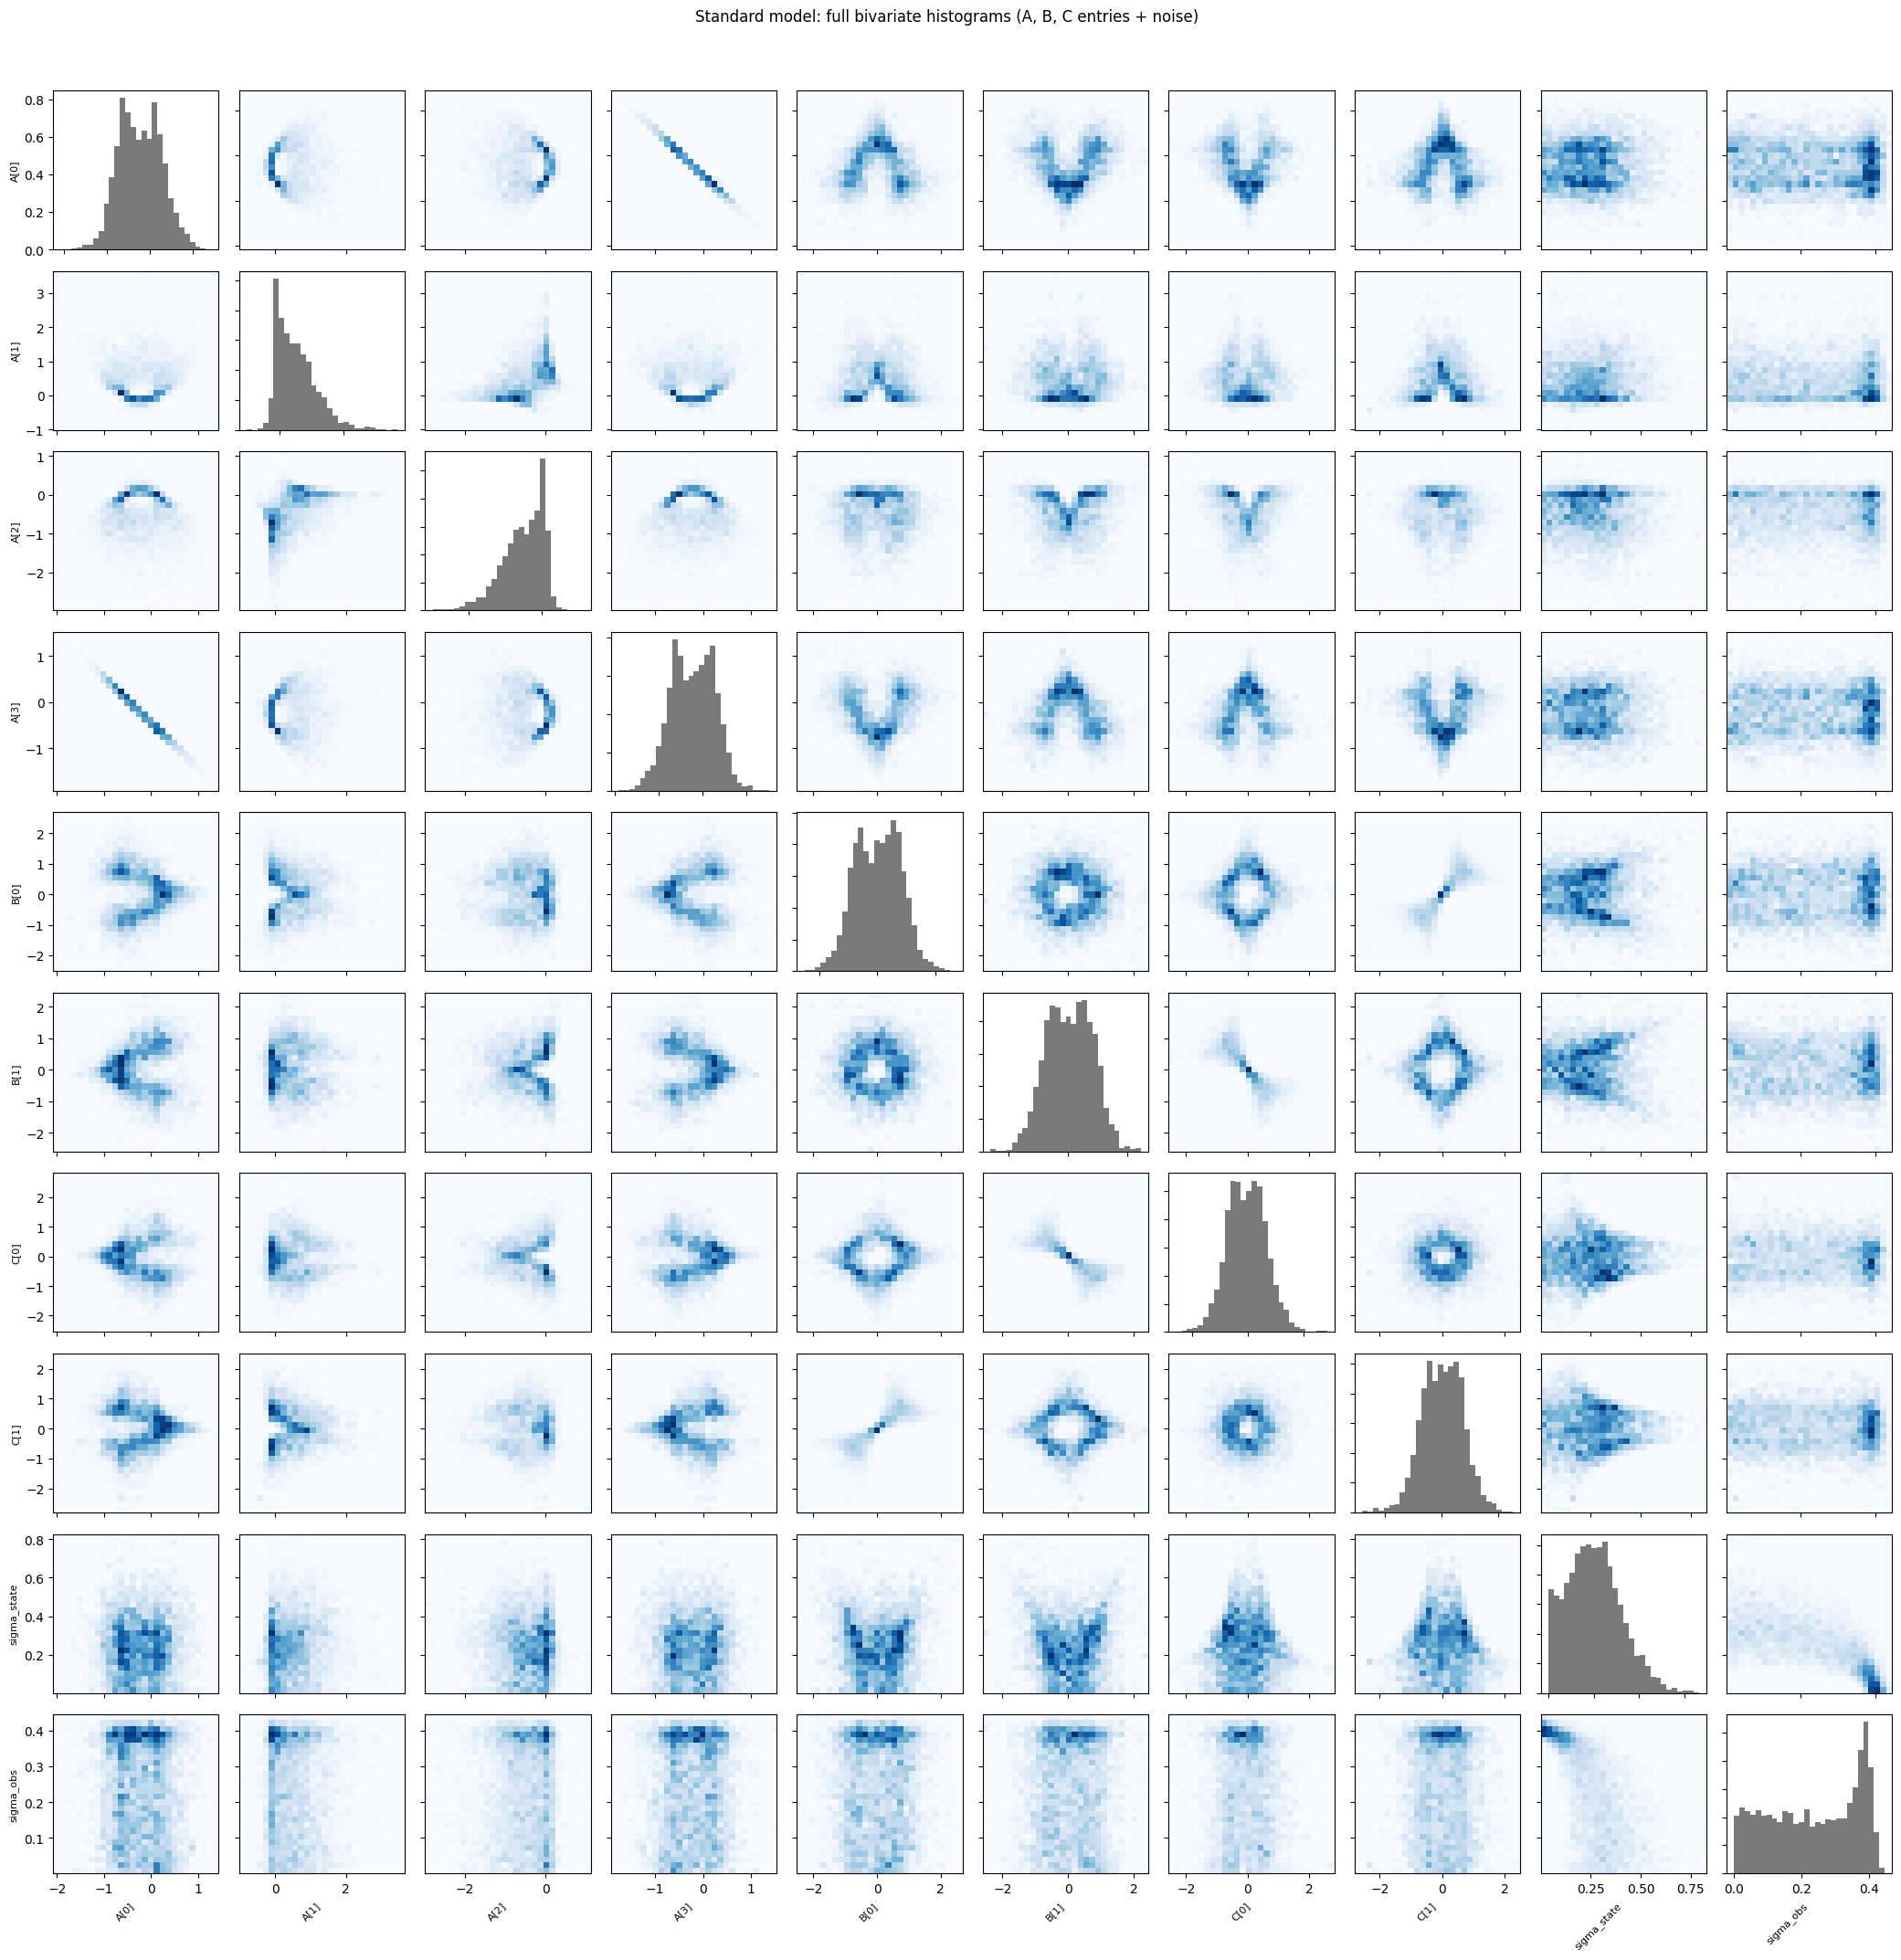

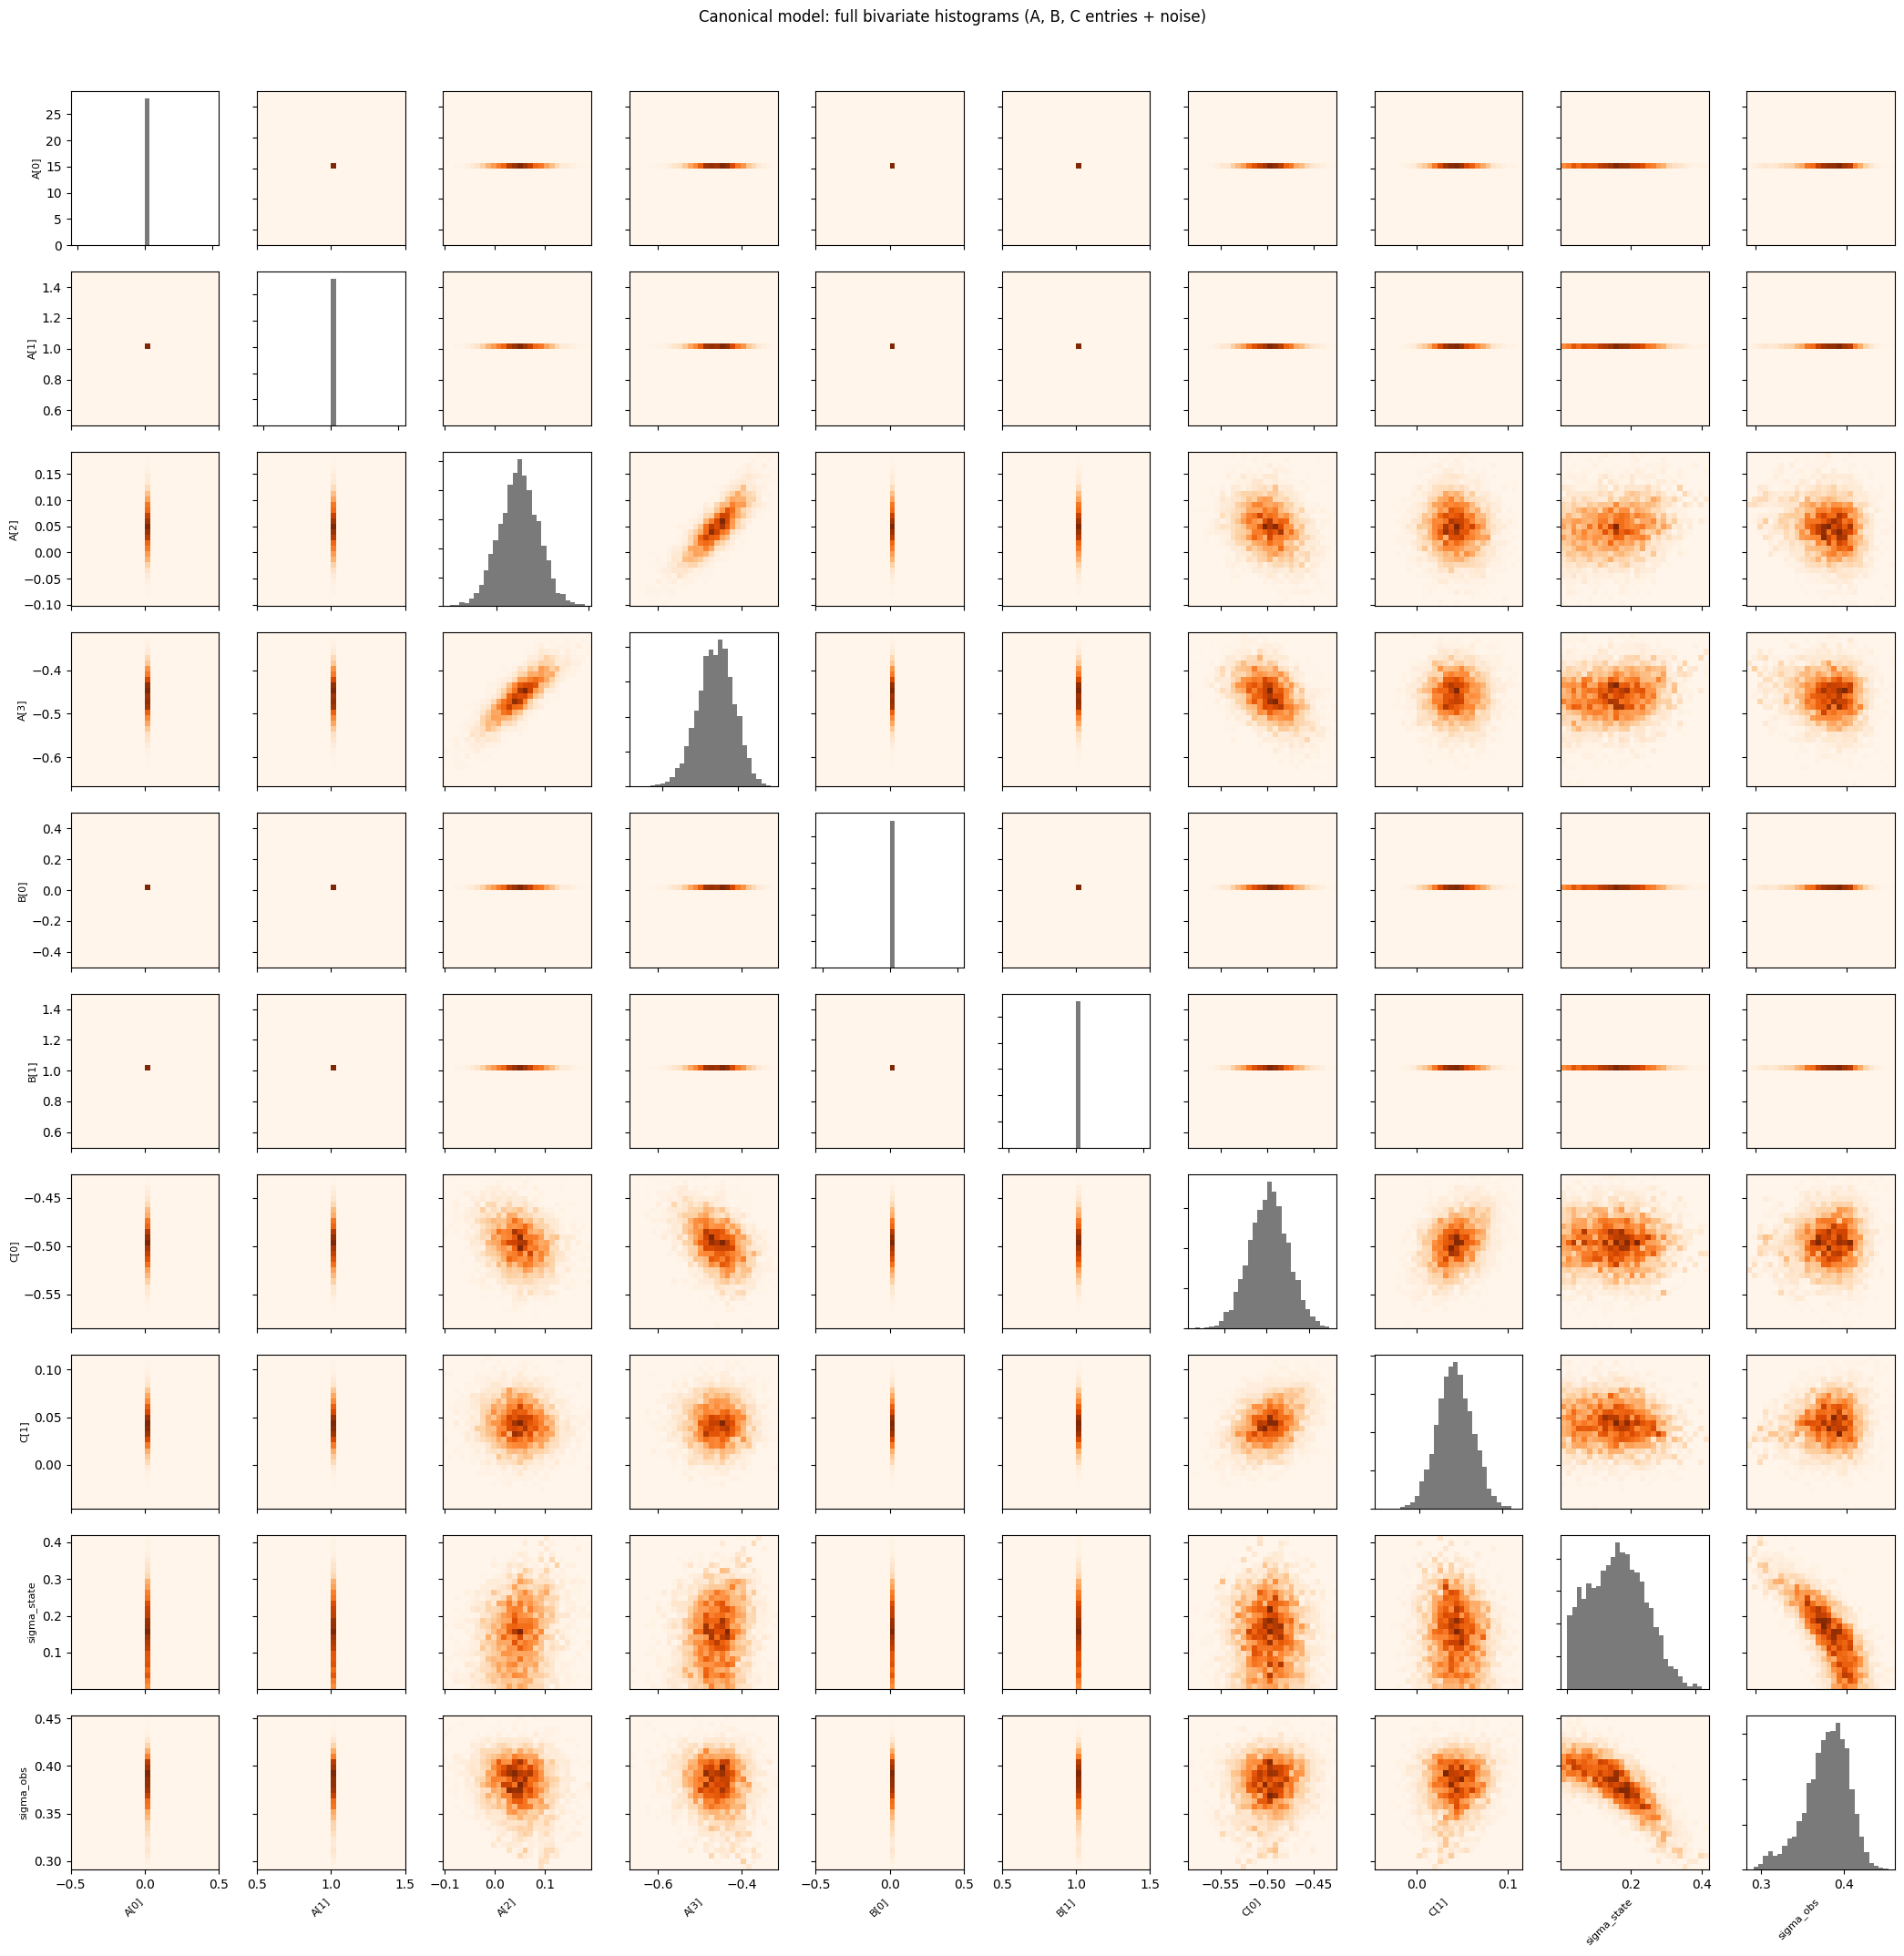

In [8]:
# Full bivariate histograms for each model's learned parameters

def flatten_parameter_block(samples, keys):
    blocks = []
    names = []
    for key in keys:
        if key not in samples:
            continue
        arr = np.array(samples[key])
        if arr.ndim == 1:
            arr = arr[:, None]
            names.append(key)
        else:
            flat = arr.reshape(arr.shape[0], -1)
            arr = flat
            names.extend([f"{key}[{i}]" for i in range(flat.shape[1])])
        blocks.append(arr)
    if not blocks:
        raise ValueError("No matching parameter keys found in samples.")
    return np.concatenate(blocks, axis=1), names


def plot_full_bivariate_hist(theta, names, title, cmap='Blues', bins=28):
    d = theta.shape[1]
    fig, axs = plt.subplots(d, d, figsize=(2.1 * d, 2.1 * d))

    for i in range(d):
        for j in range(d):
            ax = axs[i, j]
            if i == j:
                ax.hist(theta[:, j], bins=bins, density=True, color='0.35', alpha=0.8)
            else:
                ax.hist2d(theta[:, j], theta[:, i], bins=bins, cmap=cmap)

            if i < d - 1:
                ax.set_xticklabels([])
            else:
                ax.set_xlabel(names[j], fontsize=8, rotation=45, ha='right')
            if j > 0:
                ax.set_yticklabels([])
            else:
                ax.set_ylabel(names[i], fontsize=8)

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()


standard_theta, standard_names = flatten_parameter_block(
    post_std,
    keys=['A', 'B', 'C', 'sigma_state', 'sigma_obs'],
)

post_can_plot = dict(post_can)
if 'B' not in post_can_plot:
    n_can = post_can_plot['A'].shape[0]
    post_can_plot['B'] = np.broadcast_to(np.array([[0.0], [1.0]]), (n_can, STATE_DIM, CONTROL_DIM))

canonical_theta, canonical_names = flatten_parameter_block(
    post_can_plot,
    keys=['A', 'B', 'C', 'sigma_state', 'sigma_obs'],
)

plot_full_bivariate_hist(
    standard_theta,
    standard_names,
    title='Standard model: full bivariate histograms (A, B, C entries + noise)',
    cmap='Blues',
)

plot_full_bivariate_hist(
    canonical_theta,
    canonical_names,
    title='Canonical model: full bivariate histograms (A, B, C entries + noise)',
    cmap='Oranges',
)

## 4) Predictive performance and posterior predictive intervals

We compare posterior predictive trajectories for observed `y_t` under both parameterizations.

For each model we:

- draw parameter samples from the posterior,
- simulate forward under the observed controls,
- compute posterior predictive median and 90% intervals,
- report RMSE of posterior predictive median against observed data.

RMSE (standard median predictor):  0.4046
RMSE (canonical median predictor): 0.4061


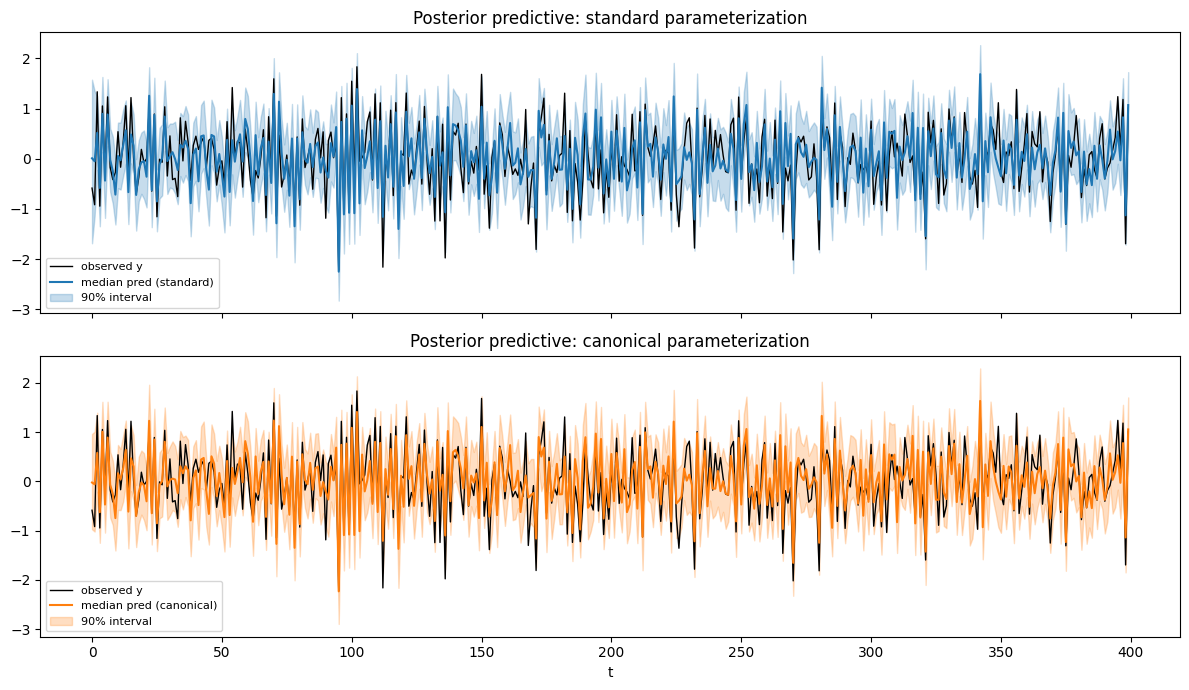

In [9]:
def subset_samples(samples, n_keep=300):
    n = list(samples.values())[0].shape[0]
    idx = np.linspace(0, n - 1, min(n, n_keep), dtype=int)
    keep = [
        'A',
        'B',
        'C',
        'sigma_state',
        'sigma_obs',
        'a0',
        'a1',
        'tri_u',
        'tri_v',
        'lambda1_real',
        'lambda1_imag',
        'lambda2_real',
        'lambda2_imag',
    ]
    return {k: v[idx] for k, v in samples.items() if k in keep}


def posterior_predictive(base_model, posterior_samples, key):
    pred = Predictive(
        base_model,
        posterior_samples=posterior_samples,
        exclude_deterministic=False,
    )
    with DiscreteTimeSimulator():
        out = pred(key, obs_times=obs_times, ctrl_times=ctrl_times, ctrl_values=ctrl_values)
    return out['observations'][..., 0]


rng, kpp_std, kpp_can = jr.split(rng, 3)
post_std_small = subset_samples(post_std, n_keep=300)
post_can_small = subset_samples(post_can, n_keep=300)

yhat_std = posterior_predictive(standard_model, post_std_small, kpp_std)
yhat_can = posterior_predictive(canonical_model, post_can_small, kpp_can)

def summarize_pred(yhat, y):
    lo = np.quantile(yhat, 0.05, axis=0)
    md = np.quantile(yhat, 0.50, axis=0)
    hi = np.quantile(yhat, 0.95, axis=0)
    rmse = np.sqrt(np.mean((md - np.array(y[:, 0])) ** 2))
    return lo, md, hi, rmse

lo_s, md_s, hi_s, rmse_s = summarize_pred(np.array(yhat_std), y_obs)
lo_c, md_c, hi_c, rmse_c = summarize_pred(np.array(yhat_can), y_obs)

print(f'RMSE (standard median predictor):  {rmse_s:.4f}')
print(f'RMSE (canonical median predictor): {rmse_c:.4f}')

ix = np.arange(T)
fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axs[0].plot(ix, np.array(y_obs[:, 0]), color='k', lw=1, label='observed y')
axs[0].plot(ix, md_s, color='C0', lw=1.5, label='median pred (standard)')
axs[0].fill_between(ix, lo_s, hi_s, color='C0', alpha=0.25, label='90% interval')
axs[0].set_title('Posterior predictive: standard parameterization')
axs[0].legend(fontsize=8)

axs[1].plot(ix, np.array(y_obs[:, 0]), color='k', lw=1, label='observed y')
axs[1].plot(ix, md_c, color='C1', lw=1.5, label='median pred (canonical)')
axs[1].fill_between(ix, lo_c, hi_c, color='C1', alpha=0.25, label='90% interval')
axs[1].set_title('Posterior predictive: canonical parameterization')
axs[1].set_xlabel('t')
axs[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5) Discussion

### Identifiability and geometry

- The standard parameterization is often weakly identified under partial observation (`d_y < d_x`), creating elongated or multi-modal posterior geometry in raw matrix entries.
- Canonical coordinates reduce equivalent representations by constraining `A` and fixing `B = [[0], [1]]`.
- In this setup, the canonical model learns only `a0, a1, C` and noise scales, which removes extra degrees of freedom in `B`.

### Stability behavior

- Compare posterior mass with spectral radius `< 1`.
- Canonical priors can place stronger and more interpretable mass over stable dynamics.

### Predictive behavior

- Even when raw parameters are hard to recover, one-step/marginal predictive fit may still be strong.
- This is why predictive intervals and RMSE are reported alongside parameter posteriors.

### Notes

- This notebook keeps everything in basic `dynestyx` (`LTI_discrete`, `Filter(KFConfig())`, `DiscreteTimeSimulator`).
- The canonical model places a uniform prior directly on `(a0, a1)` in the Schur stability triangle.
- Full bivariate posterior histograms are shown for each model; the standard model has more parameters than the canonical one.
- Eigenvalue summaries are reported via the roots of `z^2 + a1 z + a0 = 0`.

Reference on canonical Bayesian identification: https://arxiv.org/abs/2507.11535